In [1]:
#Cargar librerias
import pandas as pd
import os
import tarfile
import urllib.request
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import seaborn as sns
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from sklearn.preprocessing import LabelEncoder

### importar el dataset

In [2]:
data=pd.read_csv('currentPriceCrypto.csv')

In [3]:
data.head()

,timestamp,cryptocurrency,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
0,2025-06-04 20:36:49,Algorand,0.3427,-5.35,1716266.10,1.762124e+09,0.367,0.374,1.87,13,53.2,95.1,37.2,78.1
1,2025-06-04 20:48:25,Cosmos,12.0420,5.14,10520739.91,2.099178e+11,-0.278,-0.107,1.01,600,43.5,76.7,65.0,66.7
2,2025-06-04 21:28:54,Cosmos,11.7675,-6.12,642191.11,1.755367e+11,-0.255,0.211,5.69,279,49.1,60.4,32.3,77.4
3,2025-06-04 21:57:48,Ethereum,2861.2829,-11.54,5356227.76,4.786419e+13,-0.531,-0.081,5.11,3504,37.0,100.0,63.0,81.7
4,2025-06-04 22:06:40,Solana,95.3583,5.79,735971.56,2.667611e+11,0.369,0.248,1.82,3236,61.7,67.5,55.4,81.8


In [4]:
data.tail()

,timestamp,cryptocurrency,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
2058,2025-07-04 17:16:03,Cardano,0.4492,-4.66,6345791.01,8.185563e+09,0.327,0.009,2.54,1695,56.5,77.3,51.9,72.4
2059,2025-07-04 17:25:39,Ethereum,3077.3009,0.33,590629.81,2.546980e+13,-0.277,-0.143,2.31,1093,40.1,30.4,40.5,79.2
2060,2025-07-04 17:43:50,Polkadot,8.1297,11.93,24276229.78,1.224982e+11,0.216,0.001,3.07,401,51.7,93.3,41.6,71.0
2061,2025-07-04 19:31:59,Polygon,1.1212,-7.76,2126227.67,2.240884e+10,0.144,0.160,2.32,202,66.3,76.2,37.6,74.8
2062,2025-07-04 19:58:28,Ethereum,3312.5590,3.12,9458225.78,2.011575e+13,0.005,0.622,5.02,276,53.5,71.3,42.7,72.8


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2063 entries, 0 to 2062
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 2063 non-null   object 
 1   cryptocurrency            2063 non-null   object 
 2   current_price_usd         2063 non-null   float64
 3   price_change_24h_percent  2063 non-null   float64
 4   trading_volume_24h        2063 non-null   float64
 5   market_cap_usd            2063 non-null   float64
 6   social_sentiment_score    2063 non-null   float64
 7   news_sentiment_score      2063 non-null   float64
 8   news_impact_score         2063 non-null   float64
 9   social_mentions_count     2063 non-null   int64  
 10  fear_greed_index          2063 non-null   float64
 11  volatility_index          2063 non-null   float64
 12  rsi_technical_indicator   2063 non-null   float64
 13  prediction_confidence     2063 non-null   float64
dtypes: float

In [6]:
data.describe()

,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
count,2063.000000,2063.000000,2.063000e+03,2.063000e+03,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000
mean,4260.360520,-0.018042,5.889564e+06,4.568510e+13,0.011158,0.002375,3.688366,1218.317014,50.494910,76.436937,50.501503,77.123413
std,12603.767442,8.000837,7.451165e+06,1.581473e+14,0.303325,0.308788,1.712072,2501.245623,13.367164,21.245765,15.116517,6.651359
min,0.298700,-25.560000,2.060664e+05,5.022090e+07,-1.000000,-1.000000,0.070000,2.000000,0.000000,21.400000,1.400000,55.900000
25%,1.208650,-5.755000,1.835157e+06,1.113379e+10,-0.197500,-0.202000,2.390000,143.500000,41.400000,60.700000,40.250000,72.650000
50%,13.344200,0.020000,3.633502e+06,1.255924e+11,0.012000,0.007000,3.670000,409.000000,50.600000,79.000000,50.500000,76.700000
75%,84.970000,5.755000,7.111602e+06,7.634962e+11,0.215000,0.211500,4.970000,1178.000000,59.400000,100.000000,60.550000,81.100000
max,51610.923200,27.080000,1.402925e+08,1.009556e+15,1.000000,1.000000,9.530000,35578.000000,100.000000,100.000000,97.100000,100.000000


In [7]:
## codificar la variable cryptocurrency para que sea un int y poder proceasrla
encoder = LabelEncoder()
data['cryptocurrency'] = encoder.fit_transform(data['cryptocurrency'])

# Ver resultados
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))


{'Algorand': np.int64(0), 'Avalanche': np.int64(1), 'Bitcoin': np.int64(2), 'Cardano': np.int64(3), 'Chainlink': np.int64(4), 'Cosmos': np.int64(5), 'Ethereum': np.int64(6), 'Polkadot': np.int64(7), 'Polygon': np.int64(8), 'Solana': np.int64(9)}


In [8]:
data.head()

,timestamp,cryptocurrency,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
0,2025-06-04 20:36:49,0,0.3427,-5.35,1716266.10,1.762124e+09,0.367,0.374,1.87,13,53.2,95.1,37.2,78.1
1,2025-06-04 20:48:25,5,12.0420,5.14,10520739.91,2.099178e+11,-0.278,-0.107,1.01,600,43.5,76.7,65.0,66.7
2,2025-06-04 21:28:54,5,11.7675,-6.12,642191.11,1.755367e+11,-0.255,0.211,5.69,279,49.1,60.4,32.3,77.4
3,2025-06-04 21:57:48,6,2861.2829,-11.54,5356227.76,4.786419e+13,-0.531,-0.081,5.11,3504,37.0,100.0,63.0,81.7
4,2025-06-04 22:06:40,9,95.3583,5.79,735971.56,2.667611e+11,0.369,0.248,1.82,3236,61.7,67.5,55.4,81.8


In [9]:
### formatera fehca
data['timestamp'] = pd.to_datetime(data['timestamp'])

data['year'] = data['timestamp'].dt.year
data['month'] = data['timestamp'].dt.month
data['day'] = data['timestamp'].dt.day
data['hour'] = data['timestamp'].dt.hour
data['minute'] = data['timestamp'].dt.minute

In [10]:
### eliminar formato original de la fecha
data.drop('timestamp', axis=1, inplace=True)

In [11]:
data.head()

,cryptocurrency,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence,year,month,day,hour,minute
0,0,0.3427,-5.35,1716266.10,1.762124e+09,0.367,0.374,1.87,13,53.2,95.1,37.2,78.1,2025,6,4,20,36
1,5,12.0420,5.14,10520739.91,2.099178e+11,-0.278,-0.107,1.01,600,43.5,76.7,65.0,66.7,2025,6,4,20,48
2,5,11.7675,-6.12,642191.11,1.755367e+11,-0.255,0.211,5.69,279,49.1,60.4,32.3,77.4,2025,6,4,21,28
3,6,2861.2829,-11.54,5356227.76,4.786419e+13,-0.531,-0.081,5.11,3504,37.0,100.0,63.0,81.7,2025,6,4,21,57
4,9,95.3583,5.79,735971.56,2.667611e+11,0.369,0.248,1.82,3236,61.7,67.5,55.4,81.8,2025,6,4,22,6


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2063 entries, 0 to 2062
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cryptocurrency            2063 non-null   int64  
 1   current_price_usd         2063 non-null   float64
 2   price_change_24h_percent  2063 non-null   float64
 3   trading_volume_24h        2063 non-null   float64
 4   market_cap_usd            2063 non-null   float64
 5   social_sentiment_score    2063 non-null   float64
 6   news_sentiment_score      2063 non-null   float64
 7   news_impact_score         2063 non-null   float64
 8   social_mentions_count     2063 non-null   int64  
 9   fear_greed_index          2063 non-null   float64
 10  volatility_index          2063 non-null   float64
 11  rsi_technical_indicator   2063 non-null   float64
 12  prediction_confidence     2063 non-null   float64
 13  year                      2063 non-null   int32  
 14  month   

In [15]:
##comprobar que no hay datos nulos

data.isnull().sum()

cryptocurrency              0
current_price_usd           0
price_change_24h_percent    0
trading_volume_24h          0
market_cap_usd              0
social_sentiment_score      0
news_sentiment_score        0
news_impact_score           0
social_mentions_count       0
fear_greed_index            0
volatility_index            0
rsi_technical_indicator     0
prediction_confidence       0
year                        0
month                       0
day                         0
hour                        0
minute                      0
dtype: int64

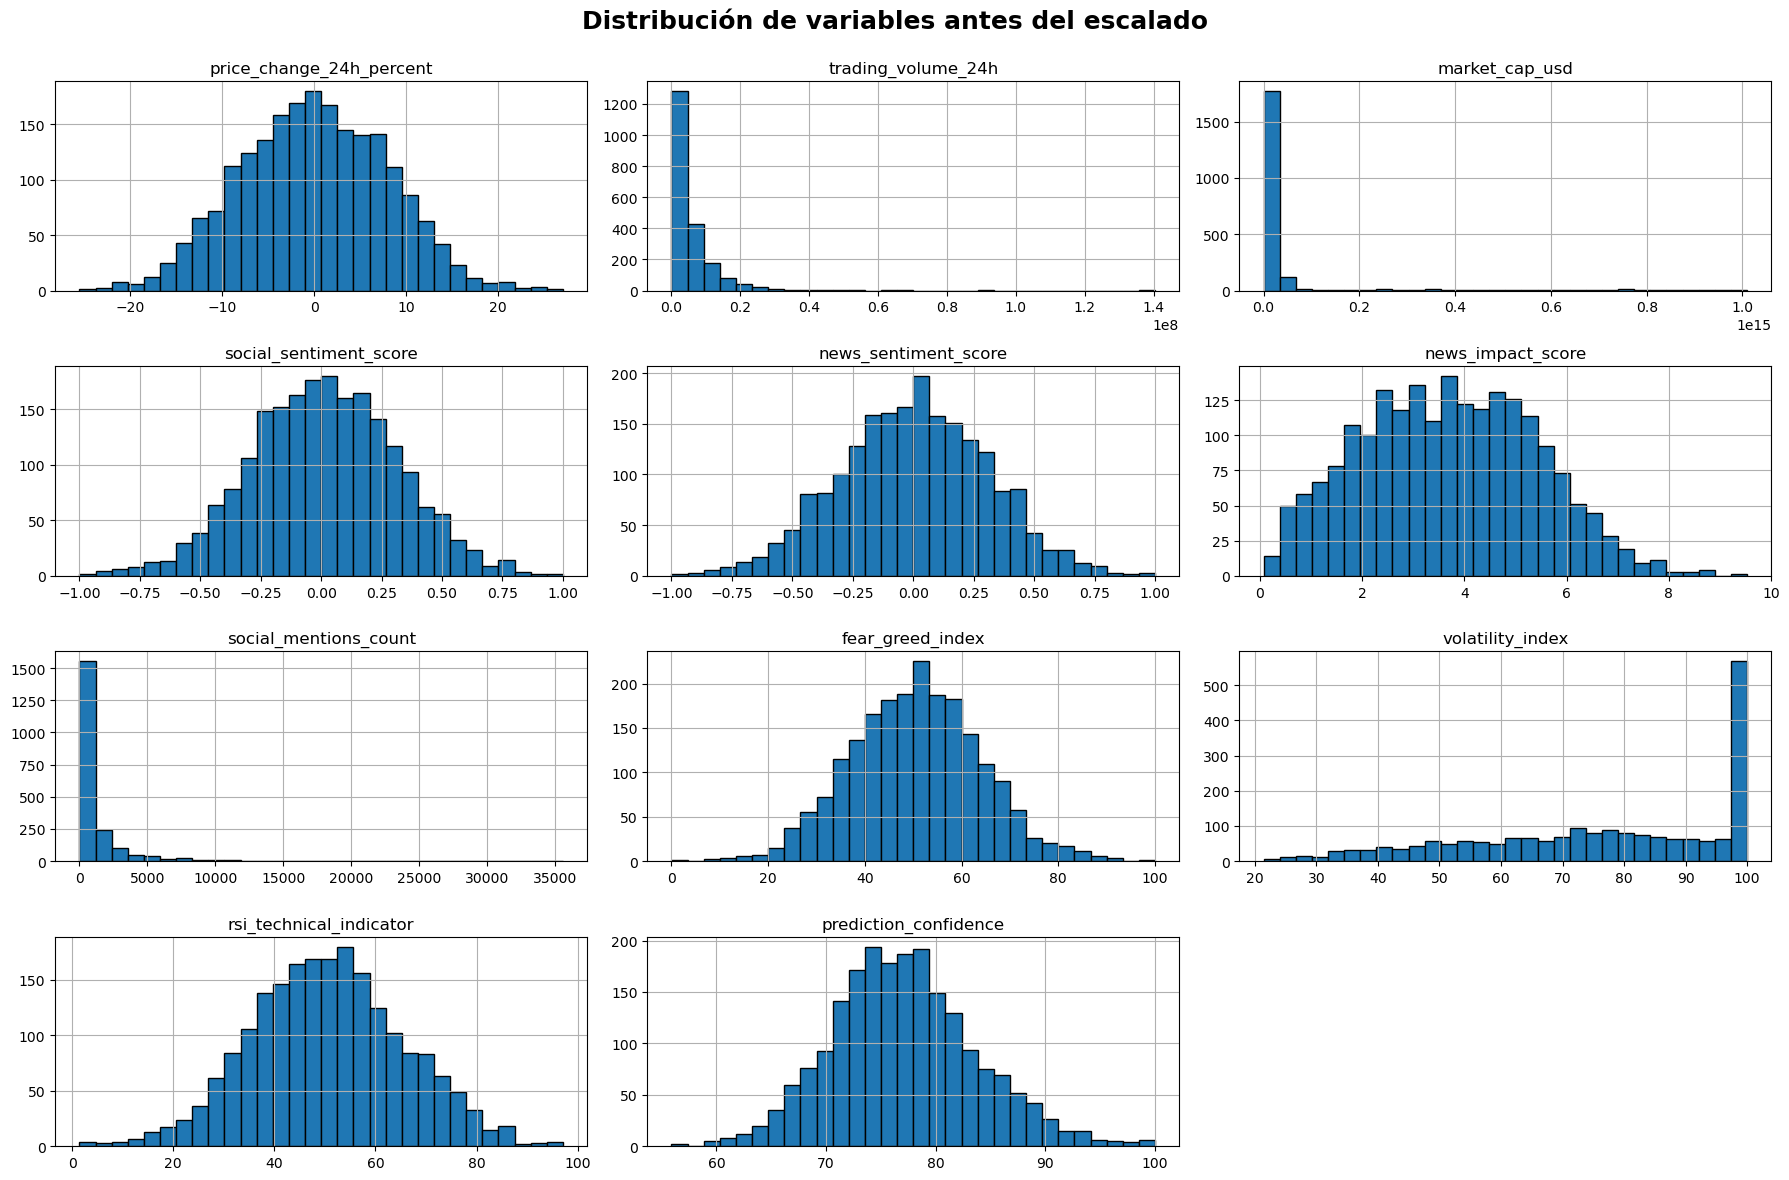

In [24]:
##grafica de datos antes de estandarizar
import matplotlib.pyplot as plt

columnas = [
    "price_change_24h_percent",
    "trading_volume_24h",
    "market_cap_usd",
    "social_sentiment_score",
    "news_sentiment_score",
    "news_impact_score",
    "social_mentions_count",
    "fear_greed_index",
    "volatility_index",
    "rsi_technical_indicator",
    "prediction_confidence"
]

# Crear histogramas
data[columnas].hist(
    figsize=(18, 12),   # tamaño general
    bins=30,            # cantidad de barras
    edgecolor="black",  # borde de barras
    layout=(4,3)        # filas y columnas
)

# Título general
plt.suptitle(
    "Distribución de variables antes del escalado",
    fontsize=18,
    fontweight="bold"
)

# Ajustar espacios
plt.tight_layout()

# Separar un poco el título
plt.subplots_adjust(top=0.92)

plt.show()